In [20]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.metrics import ( mean_absolute_error,  mean_squared_error, r2_score)

warnings.filterwarnings("ignore")


In [22]:
df = pd.read_csv("D:\\Jenga_AI_Engine\\data\\JENGA_AI_ML_TRAINING_DATASET_v1.csv")
df.head()

,project_id,location,region,building_type,house_type,area_m2,gross_area_m2,project_area_m2,bedrooms,floors,...,cement_bags,sand_m3,aggregate_m3,blocks_pcs,steel_kg,roofing_m2,hardcore_m2,target_count,has_any_natural_target,usable_for_mvp
0,BAGAMOYO_RES_BOQ_2019_001,"Bagamoyo, Coast Region, Tanzania",Bagamoyo,Residential building,Residential building,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,8172.00,NaN,NaN,1,True,True
1,BUTIAMA_STAFFHOUSE_001,"Butiama District, Mara",Mara,Staff house,Rural type two-bedroom 3-in-1 staff house,165.0,165.0,165.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,False
2,DAR_MABWEPANDE_RES_001,"Mabwepande, Dar es Salaam, Tanzania","Mabwepande, Dar es Salaam, Tanzania",Residential house,Residential house,120.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,False
3,DODOMA_RES_128M2_MAYAI_001,"Dodoma, Tanzania",Dodoma,Residential house,Residential house,128.0,128.0,128.0,NaN,NaN,...,40.37,3.30,3.30,1876.0,344.96,119.87,NaN,6,True,True
4,DOD_RES_001,Dodoma,Dodoma,Residential house,Residential house,128.0,NaN,NaN,NaN,NaN,...,145.46,13.96,5.35,2674.0,344.96,119.87,NaN,6,True,True


In [25]:
df.columns.tolist()

['project_id',
 'location',
 'region',
 'building_type',
 'house_type',
 'area_m2',
 'gross_area_m2',
 'project_area_m2',
 'bedrooms',
 'floors',
 'finishing',
 'foundation_type',
 'wall_type',
 'roof_type',
 'source_type',
 'quality_tier',
 'source_year',
 'design_family',
 'project_quality',
 'ml_role',
 'independent_design_sample',
 'training_candidate',
 'cement_bags',
 'sand_m3',
 'aggregate_m3',
 'blocks_pcs',
 'steel_kg',
 'roofing_m2',
 'hardcore_m2',
 'target_count',
 'has_any_natural_target',
 'usable_for_mvp']

In [26]:
df.shape


(21, 32)

In [27]:
df.isnull().sum()

project_id                    0
location                      1
region                        1
building_type                 0
house_type                    0
area_m2                       9
gross_area_m2                12
project_area_m2              12
bedrooms                     15
floors                       12
finishing                    18
foundation_type              10
wall_type                    13
roof_type                    10
source_type                   0
quality_tier                  3
source_year                   7
design_family                 0
project_quality               0
ml_role                       0
independent_design_sample     0
training_candidate            0
cement_bags                  13
sand_m3                      13
aggregate_m3                 13
blocks_pcs                   11
steel_kg                     13
roofing_m2                   15
hardcore_m2                  15
target_count                  0
has_any_natural_target        0
usable_f

In [29]:
numeric_columns = [
    "area_m2",
    "gross_area_m2",
    "project_area_m2",
    "bedrooms",
    "floors",
    "cement_bags",
    "sand_m3",
    "aggregate_m3",
    "blocks_pcs",
    "steel_kg",
    "roofing_m2",
    "hardcore_m2"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove duplicate project IDs
df = df.drop_duplicates(subset="project_id").copy()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (21, 32)


In [30]:
df["model_area_m2"] = (
    df["area_m2"]
    .fillna(df["gross_area_m2"])
    .fillna(df["project_area_m2"])
)

print(
    df[
        [
            "project_id",
            "area_m2",
            "gross_area_m2",
            "project_area_m2",
            "model_area_m2"
        ]
    ].head(10)
)

                   project_id  area_m2  gross_area_m2  project_area_m2  \
0   BAGAMOYO_RES_BOQ_2019_001      NaN            NaN              NaN   
1      BUTIAMA_STAFFHOUSE_001    165.0          165.0            165.0   
2      DAR_MABWEPANDE_RES_001    120.0            NaN              NaN   
3  DODOMA_RES_128M2_MAYAI_001    128.0          128.0            128.0   
4                 DOD_RES_001    128.0            NaN              NaN   
5  KWIMBA_STAFFHOUSE_2IN1_001      NaN            NaN              NaN   
6   MAWENI_RRH_STAFFHOUSE_001      NaN            NaN              NaN   
7        MBULU_STAFFHOUSE_001    165.0          165.0            165.0   
8                 MIR_RRH_001      NaN            NaN              NaN   
9                 MKALAMA_001    165.0          165.0            165.0   

   model_area_m2  
0            NaN  
1          165.0  
2          120.0  
3          128.0  
4          128.0  
5            NaN  
6            NaN  
7          165.0  
8            N

In [31]:
df["area_per_bedroom"] = np.where(
    df["bedrooms"] > 0,
    df["model_area_m2"] / df["bedrooms"],
    np.nan
)

df["area_per_floor"] = np.where(
    df["floors"] > 0,
    df["model_area_m2"] / df["floors"],
    np.nan
)

df["bedrooms_x_floors"] = (
    df["bedrooms"] * df["floors"]
)

print(
    df[
        [
            "model_area_m2",
            "bedrooms",
            "floors",
            "area_per_bedroom",
            "area_per_floor",
            "bedrooms_x_floors"
        ]
    ].head(10)
)

   model_area_m2  bedrooms  floors  area_per_bedroom  area_per_floor  \
0            NaN       NaN     NaN               NaN             NaN   
1          165.0       2.0     1.0              82.5           165.0   
2          120.0       NaN     NaN               NaN             NaN   
3          128.0       NaN     NaN               NaN             NaN   
4          128.0       NaN     NaN               NaN             NaN   
5            NaN       NaN     NaN               NaN             NaN   
6            NaN       NaN     NaN               NaN             NaN   
7          165.0       2.0     1.0              82.5           165.0   
8            NaN       NaN     NaN               NaN             NaN   
9          165.0       2.0     1.0              82.5           165.0   

   bedrooms_x_floors  
0                NaN  
1                2.0  
2                NaN  
3                NaN  
4                NaN  
5                NaN  
6                NaN  
7                2.0  


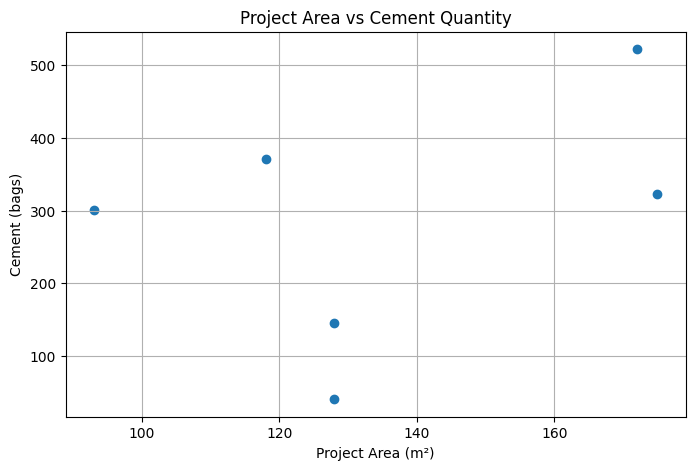

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["model_area_m2"],
    df["cement_bags"],
)

plt.xlabel("Project Area (m²)")
plt.ylabel("Cement (bags)")
plt.title("Project Area vs Cement Quantity")
plt.grid(True)

plt.show()

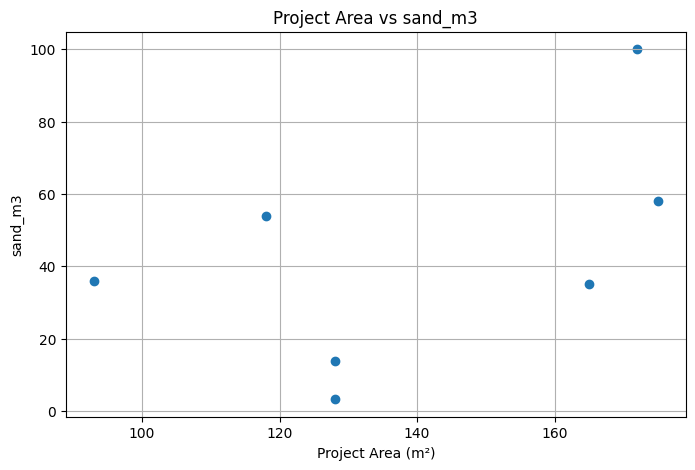

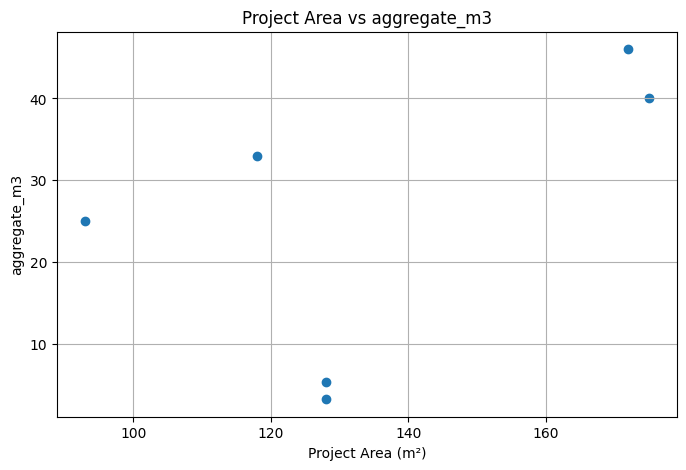

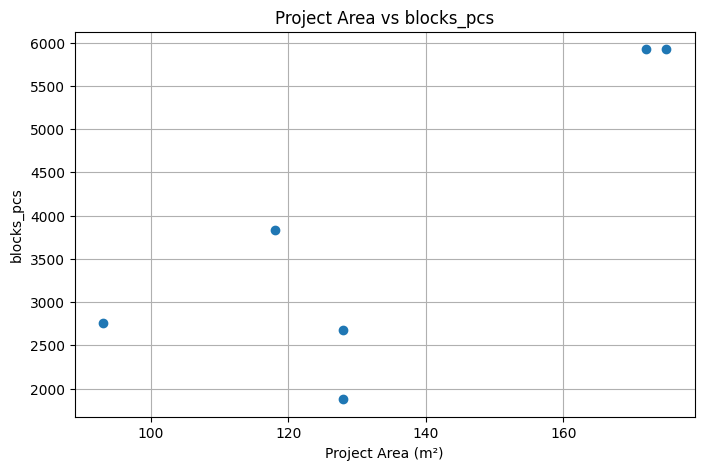

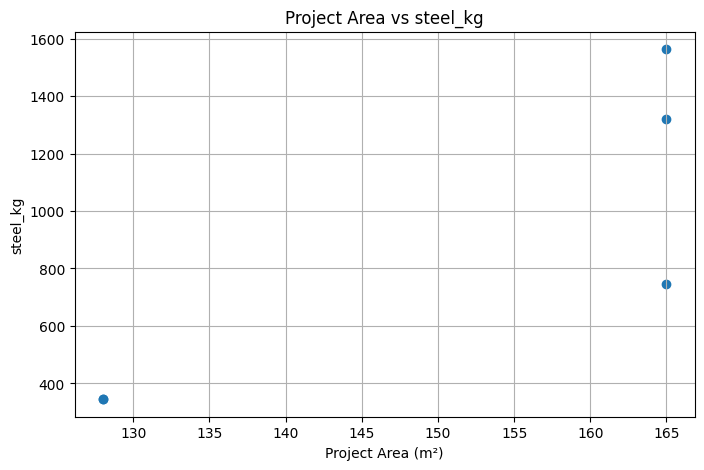

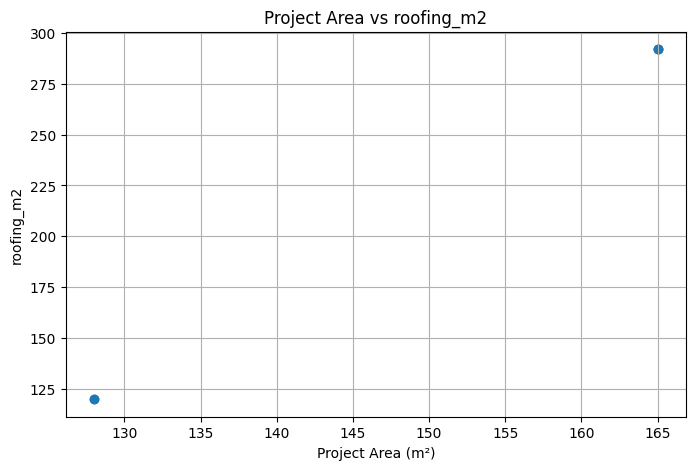

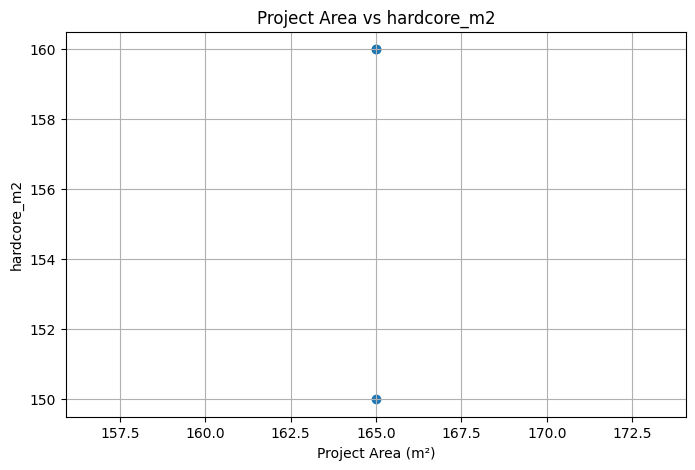

In [33]:
visualization_targets = [
    "sand_m3",
    "aggregate_m3",
    "blocks_pcs",
    "steel_kg",
    "roofing_m2",
    "hardcore_m2"
]

for target in visualization_targets:

    data = df.dropna(subset=["model_area_m2", target])

    if len(data) < 2:
        continue

    plt.figure(figsize=(8, 5))

    plt.scatter(
        data["model_area_m2"],
        data[target]
    )

    plt.xlabel("Project Area (m²)")
    plt.ylabel(target)
    plt.title(f"Project Area vs {target}")
    plt.grid(True)

    plt.show()



In [34]:
target_columns = [
    "cement_bags",
    "sand_m3",
    "aggregate_m3",
    "blocks_pcs",
    "steel_kg",
    "roofing_m2",
    "hardcore_m2"
]

print("Targets:")
print(target_columns)

Targets:
['cement_bags', 'sand_m3', 'aggregate_m3', 'blocks_pcs', 'steel_kg', 'roofing_m2', 'hardcore_m2']


In [35]:
features = [
    "model_area_m2",
    "bedrooms",
    "floors",
    "area_per_bedroom",
    "area_per_floor",
    "bedrooms_x_floors",
    "region",
    "building_type",
    "house_type",
    "foundation_type",
    "wall_type",
    "roof_type",
    "finishing"
]

# Keep only columns that actually exist
features = [col for col in features if col in df.columns]

numeric_features = [
    "model_area_m2",
    "bedrooms",
    "floors",
    "area_per_bedroom",
    "area_per_floor",
    "bedrooms_x_floors"
]

numeric_features = [
    col for col in numeric_features
    if col in features
]

categorical_features = [
    col for col in features
    if col not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['model_area_m2', 'bedrooms', 'floors', 'area_per_bedroom', 'area_per_floor', 'bedrooms_x_floors']

Categorical features:
['region', 'building_type', 'house_type', 'foundation_type', 'wall_type', 'roof_type', 'finishing']


In [36]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),

    "Ridge": Ridge(alpha=10.0)
}

print("Models ready:")
for name in models:
    print("-", name)

Models ready:
- Random Forest
- Extra Trees
- Gradient Boosting
- Ridge


In [37]:
def create_preprocessor():
    
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )

    return preprocessor


def create_pipeline(model):

    pipeline = Pipeline([
        (
            "preprocessing",
            create_preprocessor()
        ),
        (
            "model",
            model
        )
    ])

    return pipeline

In [38]:
results = []

for target in target_columns:

    target_data = df.dropna(
        subset=[target]
    ).copy()

    if len(target_data) < 5:
        print(
            f"Skipping {target}: "
            f"only {len(target_data)} projects."
        )
        continue

    X = target_data[features]
    y = target_data[target]

    loo = LeaveOneOut()

    print(
        f"\nTraining target: {target} "
        f"(n={len(target_data)})"
    )

    for model_name, model in models.items():

        pipeline = create_pipeline(model)

        predictions = cross_val_predict(
            pipeline,
            X,
            y,
            cv=loo
        )

        mae = mean_absolute_error(
            y,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y,
                predictions
            )
        )

        r2 = r2_score(
            y,
            predictions
        )

        results.append({
            "target": target,
            "model": model_name,
            "n_projects": len(y),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

results_df = pd.DataFrame(results)

print("\nEvaluation completed.")
display(results_df)


Training target: cement_bags (n=8)

Training target: sand_m3 (n=8)

Training target: aggregate_m3 (n=8)

Training target: blocks_pcs (n=10)

Training target: steel_kg (n=8)

Training target: roofing_m2 (n=6)

Training target: hardcore_m2 (n=6)

Evaluation completed.


,target,model,n_projects,MAE,RMSE,R2
0,cement_bags,Random Forest,8,249.571569,354.384089,-0.226819
1,cement_bags,Extra Trees,8,251.083728,347.576048,-0.180135
2,cement_bags,Gradient Boosting,8,225.889025,334.471870,-0.092826
3,cement_bags,Ridge,8,426.575524,585.832115,-2.352573
4,sand_m3,Random Forest,8,22.931947,30.503421,-0.214208
5,sand_m3,Extra Trees,8,26.489220,34.758497,-0.576587
6,sand_m3,Gradient Boosting,8,23.565969,32.079900,-0.342957
7,sand_m3,Ridge,8,56.450426,101.411284,-12.420496
8,aggregate_m3,Random Forest,8,214.543410,285.105030,-0.558972
9,aggregate_m3,Extra Trees,8,219.125833,291.600722,-0.630819


In [39]:
best_models_df = (
    results_df
    .sort_values(
        ["target", "MAE"]
    )
    .groupby("target", as_index=False)
    .first()
)

print("Best model per target:")
display(best_models_df)

Best model per target:


,target,model,n_projects,MAE,RMSE,R2
0,aggregate_m3,Gradient Boosting,8,97.184112,244.727831,-0.148670
1,blocks_pcs,Extra Trees,10,4901.704500,7042.012790,-0.355871
2,cement_bags,Gradient Boosting,8,225.889025,334.471870,-0.092826
3,hardcore_m2,Gradient Boosting,6,155.500722,260.118398,-0.274197
4,roofing_m2,Gradient Boosting,6,31.933354,46.921004,0.631318
5,sand_m3,Random Forest,8,22.931947,30.503421,-0.214208
6,steel_kg,Gradient Boosting,8,1728.748244,2899.181163,-0.297037


In [40]:
final_models = {}

for _, row in best_models_df.iterrows():

    target = row["target"]
    model_name = row["model"]

    target_data = df.dropna(
        subset=[target]
    ).copy()

    X = target_data[features]
    y = target_data[target]

    selected_model = models[model_name]

    pipeline = create_pipeline(
        selected_model
    )

    pipeline.fit(X, y)

    final_models[target] = pipeline

    print(
        f"{target:15} -> "
        f"{model_name:20} "
        f"(n={len(target_data)})"
    )

print("\nFinal models trained successfully.")

aggregate_m3    -> Gradient Boosting    (n=8)
blocks_pcs      -> Extra Trees          (n=10)
cement_bags     -> Gradient Boosting    (n=8)
hardcore_m2     -> Gradient Boosting    (n=6)
roofing_m2      -> Gradient Boosting    (n=6)
sand_m3         -> Random Forest        (n=8)
steel_kg        -> Gradient Boosting    (n=8)

Final models trained successfully.


In [41]:
print("Checking trained pipelines...\n")

for target, pipeline in final_models.items():

    target_data = df.dropna(
        subset=[target]
    ).copy()

    X_check = target_data[features].head(1)

    transformed = pipeline.named_steps[
        "preprocessing"
    ].transform(X_check)

    transformed_count = transformed.shape[1]

    model_count = pipeline.named_steps[
        "model"
    ].n_features_in_

    status = "OK" if transformed_count == model_count else "ERROR"

    print(
        f"{target:15} | "
        f"transformed={transformed_count:3} | "
        f"model_expects={model_count:3} | "
        f"{status}"
    )

Checking trained pipelines...

aggregate_m3    | transformed= 39 | model_expects= 33 | ERROR
blocks_pcs      | transformed= 46 | model_expects= 46 | OK
cement_bags     | transformed= 38 | model_expects= 33 | ERROR
hardcore_m2     | transformed= 27 | model_expects= 33 | ERROR
roofing_m2      | transformed= 26 | model_expects= 33 | ERROR
sand_m3         | transformed= 42 | model_expects= 42 | OK
steel_kg        | transformed= 33 | model_expects= 33 | OK


In [42]:
new_project = pd.DataFrame([{
    "model_area_m2": 120,
    "bedrooms": 3,
    "floors": 1,

    "area_per_bedroom": 40,
    "area_per_floor": 120,
    "bedrooms_x_floors": 3,

    "region": "Mbeya",
    "building_type": "Residential",
    "house_type": "Residential House",
    "foundation_type": "Strip Foundation",
    "wall_type": "Concrete Block",
    "roof_type": "Pitched Roof",
    "finishing": "Standard"
}])

# Exact same order as training
new_project = new_project.reindex(
    columns=features
)

print("New project:")
display(new_project)

New project:


,model_area_m2,bedrooms,floors,area_per_bedroom,area_per_floor,bedrooms_x_floors,region,building_type,house_type,foundation_type,wall_type,roof_type,finishing
0,120,3,1,40,120,3,Mbeya,Residential,Residential House,Strip Foundation,Concrete Block,Pitched Roof,Standard


In [43]:
test_target = "cement_bags"

cement_model = final_models[test_target]

cement_prediction = cement_model.predict(
    new_project
)[0]

print(
    f"Predicted cement quantity: "
    f"{cement_prediction:.2f} bags"
)

ValueError: X has 38 features, but GradientBoostingRegressor is expecting 33 features as input.

In [44]:
predictions = {}

for target, pipeline in final_models.items():

    prediction = pipeline.predict(
        new_project
    )[0]

    predictions[target] = prediction


prediction_df = pd.DataFrame({
    "Material": predictions.keys(),
    "Predicted Quantity": predictions.values()
})

display(prediction_df)

ValueError: X has 39 features, but GradientBoostingRegressor is expecting 33 features as input.